# Ship Detection in SAR Images — YOLOv8 + YOLOv11 + WBF Ensemble

**Based on:** Gupta et al. (2024), *"Ship detection using ensemble deep learning techniques from synthetic aperture radar imagery"*, **Scientific Reports** 14, 29397 — Q1, Nature Publishing.

**Our extension over Gupta:** v8 + v11 modern backbones (Gupta used v4+v5), 3-model ensemble (Gupta used 2), and cross-dataset validation on HRSID (Gupta did not).

### Prerequisite
- `Official-SSDD-OPEN.rar` already uploaded to your Drive at: `My Drive/ship-detection/`
- Runtime → Change runtime type → **T4 GPU**

### What this notebook does (in order)
1. Mount Drive, extract SSDD RAR → ~1,160 SAR images with bbox annotations.
2. Convert PASCAL VOC XML → YOLO format, create train/val/test splits.
3. Train Model A (YOLOv8s) → backup weights to Drive.
4. Train Model B (YOLOv11s) → backup weights to Drive.
5. Train Model C (YOLOv8m, heavy aug) → backup weights to Drive.
6. Evaluate each model individually on SSDD test set.
7. Build WBF ensemble, evaluate ensemble.
8. Generate report figures and tables.

Estimated total runtime on T4: ~90 minutes.


## 1. Environment setup

Run cells 1.1 → 1.4 in order.

In [1]:
# 1.1 — Confirm GPU
!nvidia-smi

Sun Apr 26 06:07:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1.2 — Install packages
!pip install -q ultralytics==8.3.40 ensemble-boxes==1.0.9 supervision==0.25.1 pyyaml
# Install unrar so we can extract the RAR file from Drive
!apt-get install -y -qq unrar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 18.3 MB/s eta 0:00:00


In [3]:
# 1.3 — Imports + reproducibility seed
import os, sys, shutil, random, json, yaml
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, OrderedDict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm

import torch
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion
import supervision as sv

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch : 2.10.0+cu128
CUDA  : True | Tesla T4


In [4]:
# 1.4 — Mount Drive and define folder paths
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/ship-detection')
RAR_PATH  = DRIVE_DIR / 'Official-SSDD-OPEN.rar'

PROJECT   = Path('/content/ship-detection')
DATASETS  = PROJECT / 'datasets'
SSDD_RAW  = DATASETS / 'SSDD_raw'
SSDD      = DATASETS / 'SSDD'           # YOLO-format dataset goes here
RUNS      = PROJECT / 'runs'
BACKUP    = DRIVE_DIR / 'weights'       # weights survive timeouts here

for p in [DATASETS, SSDD_RAW, RUNS, BACKUP]:
    p.mkdir(parents=True, exist_ok=True)

assert RAR_PATH.exists(), f"RAR not found at {RAR_PATH}. Check your Drive folder name."
print(f"RAR found     : {RAR_PATH}  ({RAR_PATH.stat().st_size/1e6:.0f} MB)")
print(f"Working dir   : {PROJECT}")
print(f"Drive backup  : {BACKUP}")

Mounted at /content/drive
RAR found     : /content/drive/MyDrive/ship-detection/Official-SSDD-OPEN.rar  (1043 MB)
Working dir   : /content/ship-detection
Drive backup  : /content/drive/MyDrive/ship-detection/weights


## 2. Extract SSDD RAR and locate the bounding-box folder

The RAR contains multiple annotation styles (BBox, RBox, PSeg). We only need **BBox** (horizontal bounding boxes) for YOLO.

In [5]:
# 2.1 — Extract RAR (only if not already extracted)
import subprocess

flag = SSDD_RAW / '.extracted_ok'
if not flag.exists():
    print("Extracting RAR (this takes ~3-5 min on Colab)...")
    result = subprocess.run(
        ['unrar', 'x', '-o+', '-idq', str(RAR_PATH), str(SSDD_RAW) + '/'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError("unrar failed")
    flag.touch()
    print("Extracted.")
else:
    print("Already extracted (skipping).")

print("\nTop-level contents:")
!ls {SSDD_RAW}

Extracting RAR (this takes ~3-5 min on Colab)...
Extracted.

Top-level contents:
Official-SSDD-OPEN


In [6]:
# 2.2 — Find the bounding-box VOC folder by matching XML stems to image stems
# This is robust to whatever folder names SSDD uses internally.

def find_bbox_pair(root: Path):
    '''Return (image_dir, annotation_dir) with most matching filename stems.
    Prefers folders containing "BBox" in the path (horizontal bboxes for YOLO).'''
    img_stems_by_dir = {}
    for ext in ('*.jpg', '*.jpeg', '*.png'):
        for img in root.rglob(ext):
            img_stems_by_dir.setdefault(img.parent, set()).add(img.stem)

    xml_stems_by_dir = {}
    for xml in root.rglob('*.xml'):
        xml_stems_by_dir.setdefault(xml.parent, set()).add(xml.stem)

    print(f"Found {len(img_stems_by_dir)} image folders, {len(xml_stems_by_dir)} XML folders")

    best = (None, None, 0, False)  # (img_dir, ann_dir, n_matches, prefers_bbox)
    for img_dir, img_stems in img_stems_by_dir.items():
        for ann_dir, ann_stems in xml_stems_by_dir.items():
            matches = len(img_stems & ann_stems)
            if matches < 100:
                continue
            # Prefer paths containing "bbox" (horizontal bboxes, not rotated)
            in_bbox = ('bbox' in str(img_dir).lower() and
                       'bbox' in str(ann_dir).lower() and
                       'rbox' not in str(img_dir).lower())
            # Pick best by (prefers_bbox first, then matches count)
            score = (in_bbox, matches)
            best_score = (best[3], best[2])
            if score > best_score:
                best = (img_dir, ann_dir, matches, in_bbox)
    return best

IMG_SRC, ANN_SRC, n_match, is_bbox = find_bbox_pair(SSDD_RAW)
assert IMG_SRC is not None and n_match >= 800, \
    f"Couldn't find good image+XML pair. Best: {n_match} matches. Run diagnostics."

print(f"\n✅ Images      : {IMG_SRC}")
print(f"✅ Annotations : {ANN_SRC}")
print(f"✅ Matched     : {n_match} pairs")
print(f"✅ BBox folder : {is_bbox}")

Found 47 image folders, 20 XML folders

✅ Images      : /content/ship-detection/datasets/SSDD_raw/Official-SSDD-OPEN/BBox_SSDD/voc_style/JPEGImages_BBox_GT
✅ Annotations : /content/ship-detection/datasets/SSDD_raw/Official-SSDD-OPEN/BBox_RBox_PSeg_SSDD/voc_style/Annotations
✅ Matched     : 1160 pairs
✅ BBox folder : True


In [7]:
# 2.3 — Quickly inspect a sample XML to verify it's bbox format (not rotated/segmentation)
sample_xml = next(ANN_SRC.glob('*.xml'))
print(f"Sample XML: {sample_xml.name}")
print("-" * 60)
print(sample_xml.read_text()[:1200])

Sample XML: 001126.xml
------------------------------------------------------------
<annotation>
	<folder>JPEGImages</folder>
	<filename>001126.jpg</filename>
	<path>JPEGImages</path>
	<size>
		<width>460</width>
		<height>260</height>
		<depth>3</depth>
	</size>
	<object>
		<name>ship</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>40</xmin>
			<ymin>108</ymin>
			<xmax>62</xmax>
			<ymax>120</ymax>
			<bbox_w>22</bbox_w>
			<bbox_h>12</bbox_h>
		</bndbox>
		<rotated_bndbox>
			<rotated_bbox_cx>51</rotated_bbox_cx>
			<rotated_bbox_cy>113</rotated_bbox_cy>
			<rotated_bbox_w>22</rotated_bbox_w>
			<rotated_bbox_h>8</rotated_bbox_h>
			<rotated_bbox_theta>21.037511825561523</rotated_bbox_theta>
			<x1>38</x1>
			<y1>114</y1>
			<x2>42</x2>
			<y2>105</y2>
			<x3>63</x3>
			<y3>113</y3>
			<x4>59</x4>
			<y4>122</y4>
		</rotated_bndbox>
		<segm>
			<point-1>62,117</point-1>
			<point-2>61,113</point-2>
			<point-3>53,110</point

## 3. Convert PASCAL VOC → YOLO and split train/val/test

**Conversion**: VOC stores absolute pixel coords `(xmin, ymin, xmax, ymax)`. YOLO needs normalized `(x_center, y_center, width, height)` in [0, 1].

**Splits** (official SSDD protocol from Zhang et al. 2021):
- Filename last digit ∈ {0, 9} → test
- Else → train+val (we carve 10% as val)


In [8]:
# 3.1 — Set up YOLO-format folders
for split in ['train', 'val', 'test']:
    (SSDD / 'images' / split).mkdir(parents=True, exist_ok=True)
    (SSDD / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Collect all images
all_imgs = sorted(list(IMG_SRC.glob('*.jpg')) + list(IMG_SRC.glob('*.png')))
print(f"Total images: {len(all_imgs)}")

# Official split
train_val, test = [], []
for p in all_imgs:
    last_char = p.stem[-1]
    (test if last_char in ('0', '9') else train_val).append(p)

# 10% of train_val → val
random.Random(SEED).shuffle(train_val)
val_size = max(1, int(0.1 * len(train_val)))
val   = train_val[:val_size]
train = train_val[val_size:]

print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")

Total images: 1160
Train: 836  Val: 92  Test: 232


In [9]:
# 3.2 — VOC → YOLO conversion function
def voc_to_yolo_lines(xml_path: Path, img_w: int, img_h: int):
    '''Parse VOC XML, return list of YOLO-format strings.'''
    tree = ET.parse(xml_path)
    lines = []
    for obj in tree.getroot().findall('object'):
        name = obj.find('name').text.strip().lower()
        if name != 'ship':
            continue
        b = obj.find('bndbox')
        xmin = float(b.find('xmin').text)
        ymin = float(b.find('ymin').text)
        xmax = float(b.find('xmax').text)
        ymax = float(b.find('ymax').text)
        xc = ((xmin + xmax) / 2) / img_w
        yc = ((ymin + ymax) / 2) / img_h
        w  = (xmax - xmin) / img_w
        h  = (ymax - ymin) / img_h
        # Clip to [0, 1]
        xc, yc = max(0, min(1, xc)), max(0, min(1, yc))
        w,  h  = max(0, min(1, w)),  max(0, min(1, h))
        lines.append(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
    return lines

# Sanity test on one file
sample_xml = next(ANN_SRC.glob('*.xml'))
sample_img = IMG_SRC / (sample_xml.stem + '.jpg')
if not sample_img.exists():
    sample_img = IMG_SRC / (sample_xml.stem + '.png')
W, H = Image.open(sample_img).size
print(f"Test on {sample_xml.name} ({W}x{H}):")
for ln in voc_to_yolo_lines(sample_xml, W, H):
    print(" ", ln)

Test on 001126.xml (460x260):
  0 0.110870 0.438462 0.047826 0.046154
  0 0.206522 0.625000 0.043478 0.034615
  0 0.520652 0.292308 0.045652 0.046154
  0 0.551087 0.540385 0.050000 0.042308
  0 0.738043 0.705769 0.045652 0.042308
  0 0.758696 0.309615 0.065217 0.057692
  0 0.940217 0.528846 0.045652 0.042308


In [10]:
# 3.3 — Process all splits: copy images + write YOLO label files
def process_split(files, name):
    n_boxes = n_empty = 0
    for img_path in tqdm(files, desc=name):
        # Copy image
        dst = SSDD / 'images' / name / img_path.name
        if not dst.exists():
            shutil.copy(img_path, dst)
        # Find matching XML
        xml = ANN_SRC / (img_path.stem + '.xml')
        label_path = SSDD / 'labels' / name / (img_path.stem + '.txt')
        if not xml.exists():
            label_path.write_text('')
            n_empty += 1
            continue
        W, H = Image.open(img_path).size
        lines = voc_to_yolo_lines(xml, W, H)
        n_boxes += len(lines)
        label_path.write_text('\n'.join(lines))
    print(f"  {name}: {len(files)} imgs, {n_boxes} boxes, {n_empty} empty")

process_split(train, 'train')
process_split(val,   'val')
process_split(test,  'test')

train: 100%|██████████| 836/836 [00:00<00:00, 1661.17it/s]


  train: 836 imgs, 1858 boxes, 0 empty


val: 100%|██████████| 92/92 [00:00<00:00, 1072.25it/s]


  val: 92 imgs, 191 boxes, 0 empty


test: 100%|██████████| 232/232 [00:00<00:00, 1284.92it/s]

  test: 232 imgs, 538 boxes, 0 empty


In [11]:
# 3.4 — Write the dataset YAML config
ssdd_yaml_path = SSDD / 'ssdd.yaml'
yaml.safe_dump({
    'path' : str(SSDD),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'names': {0: 'ship'},
}, open(ssdd_yaml_path, 'w'), sort_keys=False)

print(f"Config: {ssdd_yaml_path}")
!cat {ssdd_yaml_path}

Config: /content/ship-detection/datasets/SSDD/ssdd.yaml
path: /content/ship-detection/datasets/SSDD
train: images/train
val: images/val
test: images/test
names:
  0: ship


## 4. Sanity check — visualize labeled samples

If boxes don't sit on ships, the VOC→YOLO conversion is broken. Fix this **before** training.

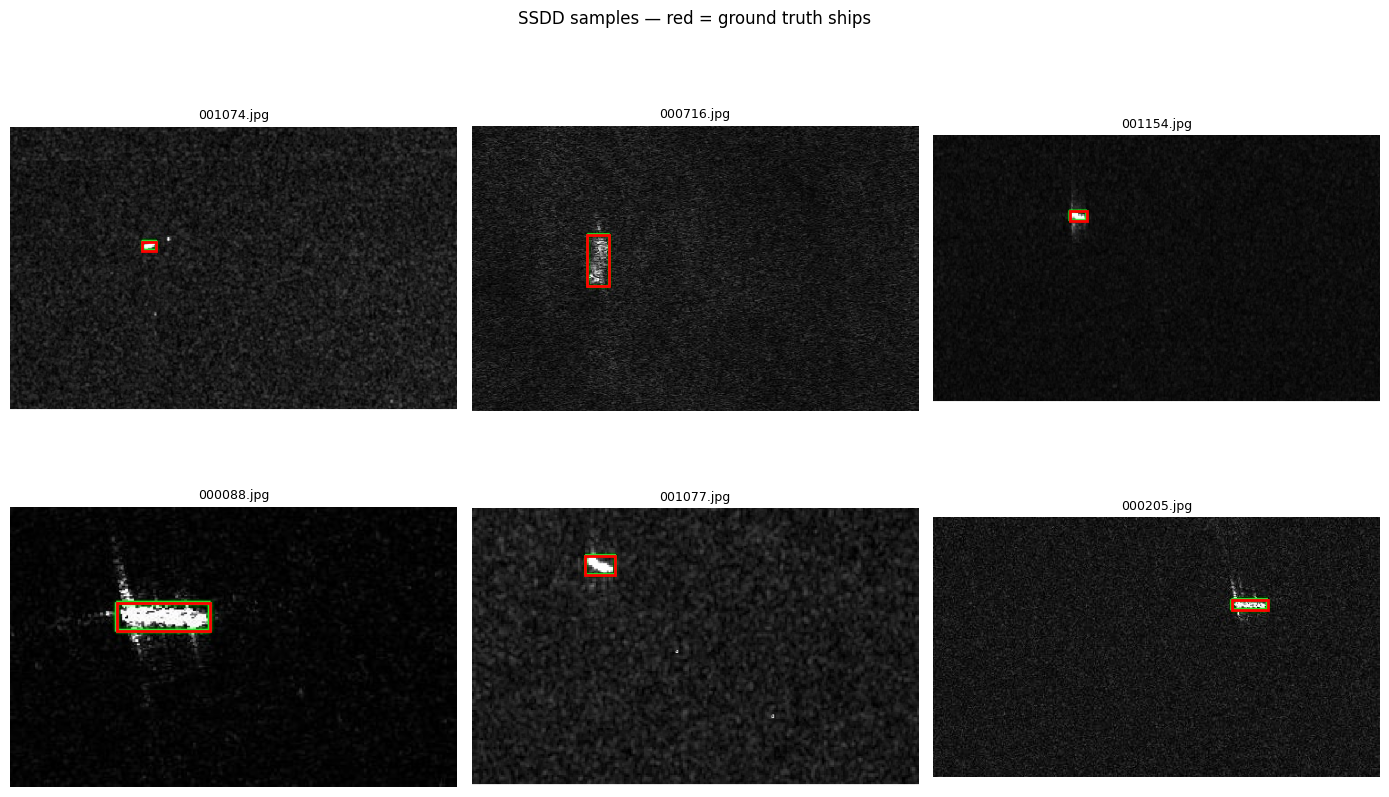

In [12]:
# 4.1 — Draw 6 random training images with their boxes
def show_sample(img_path: Path, label_path: Path, ax):
    img = np.array(Image.open(img_path).convert('RGB'))
    H, W = img.shape[:2]
    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            if not line.strip(): continue
            _, xc, yc, w, h = map(float, line.split())
            x = (xc - w/2) * W; y = (yc - h/2) * H
            ax.add_patch(plt.Rectangle((x, y), w*W, h*H,
                                        fill=False, ec='red', lw=2))
    ax.set_title(img_path.name, fontsize=9); ax.axis('off')

samples = random.Random(SEED).sample(train, 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for f, ax in zip(samples, axes.flat):
    lbl = SSDD / 'labels' / 'train' / (f.stem + '.txt')
    img = SSDD / 'images' / 'train' / f.name
    show_sample(img, lbl, ax)
plt.suptitle('SSDD samples — red = ground truth ships', fontsize=12)
plt.tight_layout(); plt.show()

## 5. Train Model A — YOLOv8s (baseline)

YOLOv8 small. Standard COCO-pretrained start. Moderate augmentation.

In [13]:
# 5.1 — Train Model A: YOLOv8s
model_a = YOLO('yolov8s.pt')
results_a = model_a.train(
    data         = str(ssdd_yaml_path),
    epochs       = 100,
    imgsz        = 512,
    batch        = 16,
    patience     = 15,
    optimizer    = 'SGD',
    lr0          = 0.01, lrf = 0.01,
    momentum     = 0.937, weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    mixup        = 0.0,
    degrees      = 0.0,
    fliplr       = 0.5, flipud = 0.0,
    hsv_h = 0.015, hsv_s = 0.5, hsv_v = 0.3,
    project      = str(RUNS),
    name         = 'modelA_yolov8s',
    exist_ok     = True,
    seed         = SEED,
    plots        = True,
)
shutil.copy(model_a.trainer.best, BACKUP / 'modelA_best.pt')
print(f"\n✅ Model A done → {BACKUP / 'modelA_best.pt'}")

100%|██████████| 21.5M/21.5M [00:00<00:00, 91.3MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/ship-detection/datasets/SSDD/ssdd.yaml, epochs=100, time=None, patience=15, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/ship-detection/runs, name=modelA_yolov8s, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, re

100%|██████████| 755k/755k [00:00<00:00, 22.6MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 98.9MB/s]


...

     96/100      2.51G     0.1847      0.155     0.7749          4        512: 100%|██████████| 53/53 [00:11<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.35it/s]

                   all         92        191          1      0.999      0.995      0.975
EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 81, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



96 epochs completed in 0.381 hours.
Optimizer stripped from /content/ship-detection/runs/modelA_yolov8s/weights/last.pt, 22.5MB
Optimizer stripped from /content/ship-detection/runs/modelA_yolov8s/weights/best.pt, 22.5MB

Validating /content/ship-detection/runs/modelA_yolov8s/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.71it/s]


                   all         92        191      0.994          1      0.995      0.981
Speed: 0.2ms preprocess, 3.7ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/ship-detection/runs/modelA_yolov8s

✅ Model A done → /content/drive/MyDrive/ship-detection/weights/modelA_best.pt


## 6. Train Model B — YOLOv11s

Newer architecture (C3k2 + C2PSA blocks). Different seed and augmentation → ensemble diversity.

In [14]:
# 6.0 Apply the fitness patch
# R1 — train Model B with strict-IoU
# Patch DetMetrics so it uses only mAP@0.5:0.95 instead of mAP@0.5
from ultralytics.utils.metrics import DetMetrics

def strict_fitness(self):
    if hasattr(self, 'box'):
# Custom fitness: weight mAP@0.5:0.95 = 1.0, ignore mAP@0.5 (which is saturated)
        return float(self.box.map)  # mAP@0.5:0.95 only
    return 0.0

DetMetrics.fitness = property(strict_fitness)
print("✅ Fitness patch applied — early-stopping now tracks mAP@0.5:0.95")

✅ Fitness patch applied — early-stopping now tracks mAP@0.5:0.95


In [15]:
# 6.1 — Train Model B: YOLOv11s
model_b = YOLO('yolo11s.pt')
results_b = model_b.train(
    data         = str(ssdd_yaml_path),
    epochs       = 150,
    imgsz        = 512,
    batch        = 16,
    patience     = 30,
    optimizer    = 'SGD',
    lr0          = 0.01, lrf = 0.01,
    momentum     = 0.937, weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    mixup        = 0.10,
    degrees      = 10.0,
    fliplr       = 0.5, flipud = 0.5,
    hsv_h = 0.015, hsv_s = 0.6, hsv_v = 0.4,
    project      = str(RUNS),
    name         = 'modelB_yolo11s',
    exist_ok     = True,
    seed         = SEED + 1,
    plots        = True,
)
shutil.copy(model_b.trainer.best, BACKUP / 'modelB_best.pt')
print(f"\n✅ Model B done → {BACKUP / 'modelB_best.pt'}")

100%|██████████| 18.4M/18.4M [00:00<00:00, 147MB/s] 


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/ship-detection/datasets/SSDD/ssdd.yaml, epochs=150, time=None, patience=30, batch=16, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/ship-detection/runs, name=modelB_yolo11s, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=43, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, re

train: Scanning /content/ship-detection/datasets/SSDD/labels/train.cache... 836 images, 0 backgrounds, 0 corrupt: 100%|██████████| 836/836 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/ship-detection/datasets/SSDD/labels/val.cache... 92 images, 0 backgrounds, 0 corrupt: 100%|██████████| 92/92 [00:00<?, ?it/s]


...

     72/150      3.01G     0.5632     0.3356     0.8346         14        512: 100%|██████████| 53/53 [00:13<00:00,  3.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.28it/s]

                   all         92        191      0.986      0.995      0.995      0.897
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 42, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



72 epochs completed in 0.317 hours.
Optimizer stripped from /content/ship-detection/runs/modelB_yolo11s/weights/last.pt, 19.2MB
Optimizer stripped from /content/ship-detection/runs/modelB_yolo11s/weights/best.pt, 19.2MB

Validating /content/ship-detection/runs/modelB_yolo11s/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.31it/s]


                   all         92        191      0.982      0.995      0.994      0.907
Speed: 0.2ms preprocess, 3.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/ship-detection/runs/modelB_yolo11s

✅ Model B done → /content/drive/MyDrive/ship-detection/weights/modelB_best.pt


## 7. Train Model C — YOLOv8m with heavy augmentation

Bigger backbone + stronger augmentation = different mistakes than A/B = stronger ensemble.

In [16]:
# 7.1 — Train Model C: YOLOv8m heavy-aug
model_c = YOLO('yolov8m.pt')
results_c = model_c.train(
    data         = str(ssdd_yaml_path),
    epochs       = 150,
    imgsz        = 512,
    batch        = 8,
    patience     = 30,
    optimizer    = 'SGD',
    lr0          = 0.01, lrf = 0.01,
    momentum     = 0.937, weight_decay = 0.0005,
    warmup_epochs= 3,
    mosaic       = 1.0,
    mixup        = 0.20,
    degrees      = 20.0,
    translate    = 0.15, scale = 0.5,
    fliplr       = 0.5,  flipud = 0.5,
    hsv_h = 0.02, hsv_s = 0.7, hsv_v = 0.5,
    copy_paste   = 0.1,
    project      = str(RUNS),
    name         = 'modelC_yolov8m_heavyaug',
    exist_ok     = True,
    seed         = SEED + 2,
    plots        = True,
)
shutil.copy(model_c.trainer.best, BACKUP / 'modelC_best.pt')
print(f"\n✅ Model C done → {BACKUP / 'modelC_best.pt'}")

100%|██████████| 49.7M/49.7M [00:00<00:00, 84.9MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/ship-detection/datasets/SSDD/ssdd.yaml, epochs=150, time=None, patience=30, batch=8, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/ship-detection/runs, name=modelC_yolov8m_heavyaug, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=44, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=

train: Scanning /content/ship-detection/datasets/SSDD/labels/train.cache... 836 images, 0 backgrounds, 0 corrupt: 100%|██████████| 836/836 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/ship-detection/datasets/SSDD/labels/val.cache... 92 images, 0 backgrounds, 0 corrupt: 100%|██████████| 92/92 [00:00<?, ?it/s]


...

    125/150      2.99G     0.4646     0.2668     0.8186         22        512: 100%|██████████| 105/105 [00:22<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  4.84it/s]

                   all         92        191          1      0.992      0.995      0.898


EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 95, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

125 epochs completed in 0.995 hours.
Optimizer stripped from /content/ship-detection/runs/modelC_yolov8m_heavyaug/weights/last.pt, 52.0MB
Optimizer stripped from /content/ship-detection/runs/modelC_yolov8m_heavyaug/weights/best.pt, 52.0MB

Validating /content/ship-detection/runs/modelC_yolov8m_heavyaug/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.82it/s]


                   all         92        191      0.995          1      0.995      0.923
Speed: 0.5ms preprocess, 6.1ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/ship-detection/runs/modelC_yolov8m_heavyaug

✅ Model C done → /content/drive/MyDrive/ship-detection/weights/modelC_best.pt


## 8. Evaluate each model on the SSDD test set

Reports: Precision, Recall, F1, mAP@0.5, mAP@0.5:0.95.

In [ ]:
# 8.1 — Run validation on test split for each model
models_cfg = [
    ('Model A — YOLOv8s',             BACKUP / 'modelA_best.pt'),
    ('Model B — YOLOv11s',            BACKUP / 'modelB_best.pt'),
    ('Model C — YOLOv8m (heavy aug)', BACKUP / 'modelC_best.pt'),
]

individual_metrics = OrderedDict()
for name, weights in models_cfg:
    print(f"\n=== Evaluating {name} ===")
    m = YOLO(str(weights))
    r = m.val(data=str(ssdd_yaml_path), split='test',
              imgsz=512, batch=16, conf=0.001, iou=0.6, verbose=False)
    P, R = r.box.mp, r.box.mr
    F1 = 2 * P * R / (P + R + 1e-9)
    individual_metrics[name] = {
        'Precision': P, 'Recall': R, 'F1': F1,
        'mAP@0.5': r.box.map50, 'mAP@0.5:0.95': r.box.map,
    }
    print(f"  P={P:.4f}  R={R:.4f}  F1={F1:.4f}  "
          f"mAP50={r.box.map50:.4f}  mAP={r.box.map:.4f}")

df_individual = pd.DataFrame(individual_metrics).T.round(4)
df_individual


=== Evaluating Model A — YOLOv8s ===
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /content/ship-detection/datasets/SSDD/labels/test.cache... 232 images, 0 backgrounds, 0 corrupt: 100%|██████████| 232/232 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/15 [00:00<?, ?it/s]

## 9. WBF ensemble — combine all three models

Weighted Box Fusion (Solovyev et al. 2021): clusters overlapping boxes from different models, fuses each cluster into a single weighted-average box. Stronger models get higher weights.

In [18]:
# 9.1 — Load models, derive weights from individual mAP@0.5
yolo_a = YOLO(str(BACKUP / 'modelA_best.pt'))
yolo_b = YOLO(str(BACKUP / 'modelB_best.pt'))
yolo_c = YOLO(str(BACKUP / 'modelC_best.pt'))
ensemble_models = [yolo_a, yolo_b, yolo_c]

# Weights ∝ individual mAP, normalized so sum = N
maps = [individual_metrics[n]['mAP@0.5'] for n, _ in models_cfg]
wbf_weights = [m / sum(maps) * len(maps) for m in maps]
print(f"WBF weights (A, B, C): {[round(w, 3) for w in wbf_weights]}")

WBF weights (A, B, C): [np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [19]:
# 9.2 — Helpers: single-model predict + ensemble predict
def predict_one(model, img_path, conf=0.001, iou=0.6, imgsz=512):
    r = model.predict(source=str(img_path), conf=conf, iou=iou,
                      imgsz=imgsz, verbose=False)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return [], [], []
    return (r.boxes.xyxyn.cpu().numpy().tolist(),
            r.boxes.conf.cpu().numpy().tolist(),
            r.boxes.cls.cpu().numpy().astype(int).tolist())


def ensemble_predict(img_path, models, weights,
                     iou_thr=0.55, skip_box_thr=0.001):
    bl, sl, ll = [], [], []
    for m in models:
        b, s, l = predict_one(m, img_path)
        bl.append(b); sl.append(s); ll.append(l)
    if all(len(b) == 0 for b in bl):
        return [], [], []
    fb, fs, fl = weighted_boxes_fusion(
        bl, sl, ll, weights=weights,
        iou_thr=iou_thr, skip_box_thr=skip_box_thr,
    )
    return fb.tolist(), fs.tolist(), fl.astype(int).tolist()

# Smoke test
sample = next((SSDD / 'images' / 'test').iterdir())
fb, fs, fl = ensemble_predict(sample, ensemble_models, wbf_weights)
print(f"{sample.name}: ensemble produced {len(fb)} boxes")

001029.jpg: ensemble produced 9 boxes


In [20]:
# 9.3 — Run ensemble on full test set, compute mAP via supervision
TEST_IMGS = SSDD / 'images' / 'test'
TEST_LBLS = SSDD / 'labels' / 'test'

def load_gt_yolo(label_path: Path, W: int, H: int):
    if not label_path.exists() or label_path.stat().st_size == 0:
        return np.zeros((0, 4)), np.zeros((0,), dtype=int)
    boxes, classes = [], []
    for line in label_path.read_text().strip().splitlines():
        c, xc, yc, w, h = map(float, line.split())
        x1, y1 = (xc - w/2) * W, (yc - h/2) * H
        x2, y2 = (xc + w/2) * W, (yc + h/2) * H
        boxes.append([x1, y1, x2, y2]); classes.append(int(c))
    return np.array(boxes), np.array(classes, dtype=int)


def evaluate_ensemble(test_img_dir, test_lbl_dir, models, weights):
    preds, gts = [], []
    for img_path in tqdm(sorted(test_img_dir.iterdir()), desc='Ensemble'):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        W, H = Image.open(img_path).size
        gb, gc = load_gt_yolo(test_lbl_dir / (img_path.stem + '.txt'), W, H)
        gts.append(sv.Detections(xyxy=gb.astype(np.float32),
                                  class_id=gc.astype(int)))

        fb, fs, fl = ensemble_predict(img_path, models, weights)
        if len(fb) == 0:
            preds.append(sv.Detections.empty()); continue
        fb_arr = np.array(fb)
        fb_arr[:, [0, 2]] *= W; fb_arr[:, [1, 3]] *= H
        preds.append(sv.Detections(
            xyxy=fb_arr.astype(np.float32),
            confidence=np.array(fs, dtype=np.float32),
            class_id=np.array(fl, dtype=int),
        ))
    return preds, gts

preds, gts = evaluate_ensemble(TEST_IMGS, TEST_LBLS, ensemble_models, wbf_weights)
map_result = sv.MeanAveragePrecision.from_detections(predictions=preds, targets=gts)
print(f"Ensemble mAP@0.5      : {map_result.map50:.4f}")
print(f"Ensemble mAP@0.5:0.95 : {map_result.map50_95:.4f}")

Ensemble: 100%|██████████| 232/232 [00:13<00:00, 17.13it/s]


Ensemble mAP@0.5      : 0.9950
Ensemble mAP@0.5:0.95 : 0.9365


In [21]:
# 9.4 — Compute Precision/Recall/F1 at conf=0.25 (standard threshold)
def pr_f1(preds, gts, conf=0.25, iou_thr=0.5):
    TP = FP = FN = 0
    for p, g in zip(preds, gts):
        keep = p.confidence >= conf if len(p) > 0 else np.array([], dtype=bool)
        pb = p.xyxy[keep] if len(p) > 0 else np.zeros((0, 4))
        gb = g.xyxy
        matched = set()
        for i in range(len(pb)):
            best_iou, best_j = 0, -1
            for j in range(len(gb)):
                if j in matched: continue
                xx1 = max(pb[i,0], gb[j,0]); yy1 = max(pb[i,1], gb[j,1])
                xx2 = min(pb[i,2], gb[j,2]); yy2 = min(pb[i,3], gb[j,3])
                inter = max(0, xx2-xx1) * max(0, yy2-yy1)
                a1 = (pb[i,2]-pb[i,0]) * (pb[i,3]-pb[i,1])
                a2 = (gb[j,2]-gb[j,0]) * (gb[j,3]-gb[j,1])
                iou = inter / (a1 + a2 - inter + 1e-9)
                if iou > best_iou: best_iou, best_j = iou, j
            if best_iou >= iou_thr: TP += 1; matched.add(best_j)
            else: FP += 1
        FN += len(gb) - len(matched)
    P = TP / (TP + FP + 1e-9)
    R = TP / (TP + FN + 1e-9)
    F1 = 2 * P * R / (P + R + 1e-9)
    return P, R, F1

P_e, R_e, F1_e = pr_f1(preds, gts)
print(f"Ensemble: P={P_e:.4f}  R={R_e:.4f}  F1={F1_e:.4f}")

# Final comparison table
df_all = df_individual.copy()
df_all.loc['Ensemble (WBF)'] = {
    'Precision': P_e, 'Recall': R_e, 'F1': F1_e,
    'mAP@0.5': map_result.map50, 'mAP@0.5:0.95': map_result.map50_95,
}
df_all = df_all.round(4)
print("\n=== Final results — SSDD test set ===")
print(df_all)

Ensemble: P=0.9926  R=0.9981  F1=0.9954

=== Final results — SSDD test set ===
                               Precision  Recall      F1  mAP@0.5  \
Model A — YOLOv8s                 0.9960  0.9981  0.9971   0.9950   
Model B — YOLOv11s                0.9907  0.9896  0.9901   0.9946   
Model C — YOLOv8m (heavy aug)     0.9976  0.9944  0.9960   0.9950   
Ensemble (WBF)                    0.9926  0.9981  0.9954   0.9950   

                               mAP@0.5:0.95  
Model A — YOLOv8s                    0.9776  
Model B — YOLOv11s                   0.9070  
Model C — YOLOv8m (heavy aug)        0.9215  
Ensemble (WBF)                       0.9365  


## 10. Save report-ready figures and tables to Drive

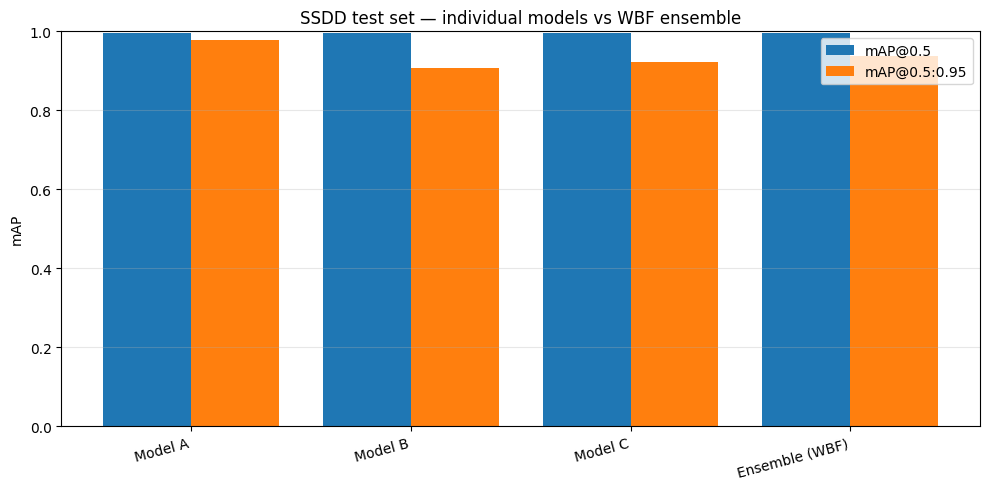

In [22]:
# 10.1 — Save table + figures to Drive
report_dir = BACKUP.parent / 'report_artifacts'
report_dir.mkdir(exist_ok=True)
df_all.to_csv(report_dir / 'results_table.csv')

# Bar chart: individual vs ensemble
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_all))
ax.bar(x - 0.2, df_all['mAP@0.5'],      width=0.4, label='mAP@0.5')
ax.bar(x + 0.2, df_all['mAP@0.5:0.95'], width=0.4, label='mAP@0.5:0.95')
ax.set_xticks(x)
ax.set_xticklabels([n.split(' — ')[0] if ' — ' in n else n for n in df_all.index],
                    rotation=15, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('mAP'); ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('SSDD test set — individual models vs WBF ensemble')
plt.tight_layout()
plt.savefig(report_dir / 'map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

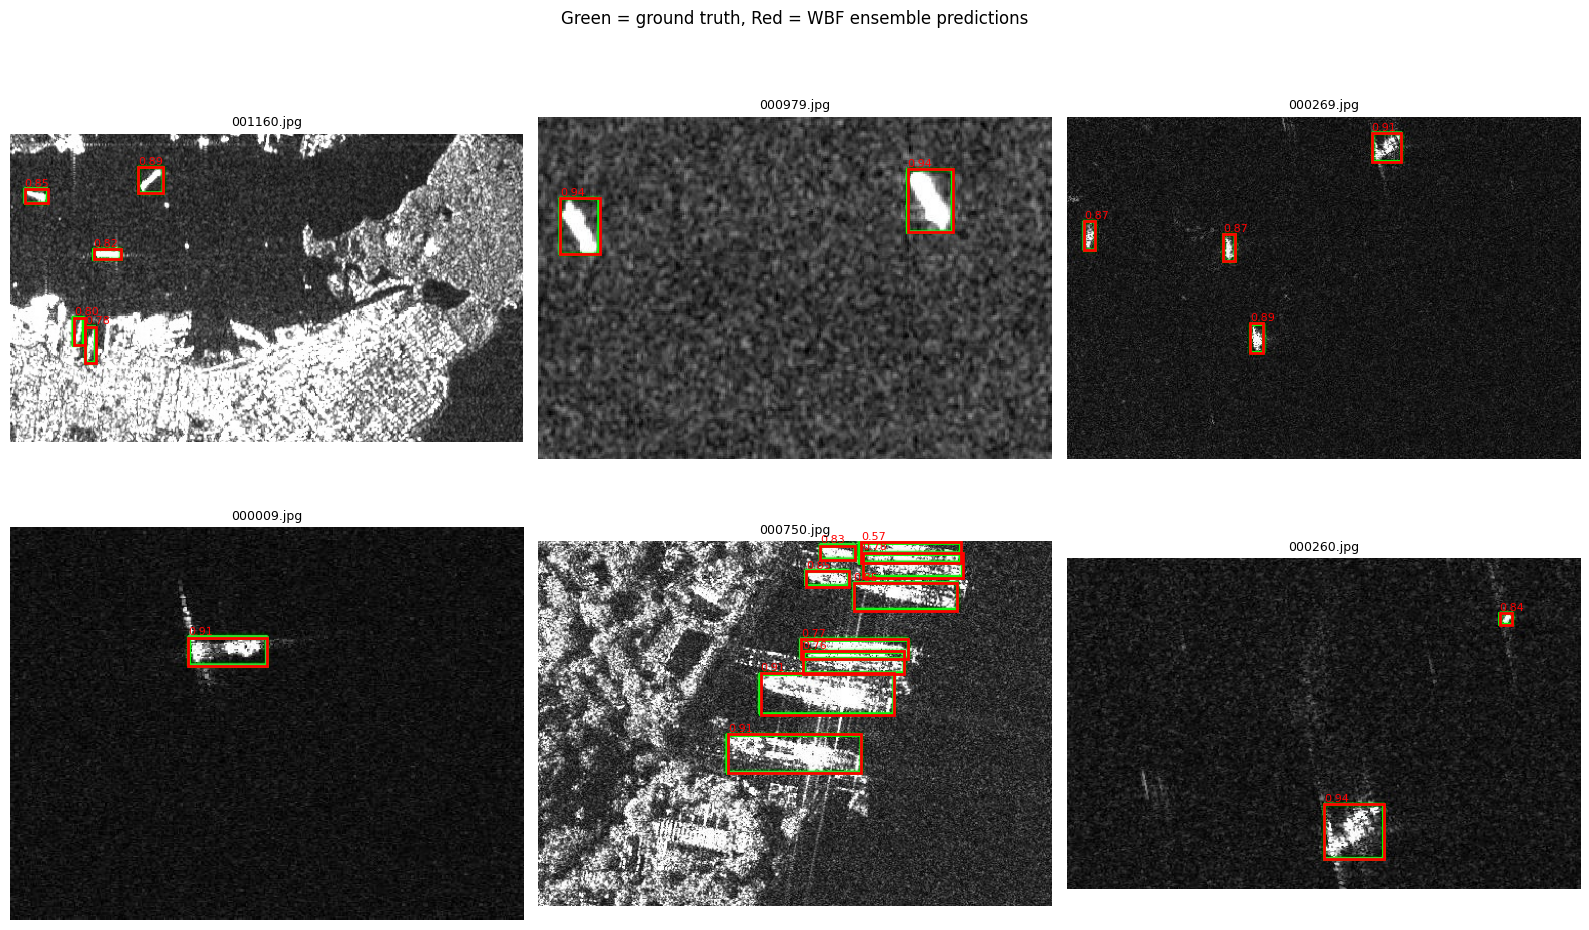


✅ All artifacts saved to: /content/drive/MyDrive/ship-detection/report_artifacts


In [23]:
# 10.2 — Qualitative samples: 6 test images with GT (green) + ensemble predictions (red)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
samples = random.Random(SEED).sample(list(TEST_IMGS.iterdir()), 6)
for img_path, ax in zip(samples, axes.flat):
    img = np.array(Image.open(img_path).convert('RGB'))
    H, W = img.shape[:2]
    ax.imshow(img)
    # Ground truth
    gb, _ = load_gt_yolo(TEST_LBLS / (img_path.stem + '.txt'), W, H)
    for b in gb:
        ax.add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                    fill=False, ec='lime', lw=2))
    # Ensemble predictions
    fb, fs, _ = ensemble_predict(img_path, ensemble_models, wbf_weights)
    for b, s in zip(fb, fs):
        if s < 0.25: continue
        x1, y1 = b[0]*W, b[1]*H
        x2, y2 = b[2]*W, b[3]*H
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                    fill=False, ec='red', lw=2))
        ax.text(x1, y1-3, f'{s:.2f}', color='red', fontsize=8)
    ax.set_title(img_path.name, fontsize=9); ax.axis('off')
plt.suptitle('Green = ground truth, Red = WBF ensemble predictions', fontsize=12)
plt.tight_layout()
plt.savefig(report_dir / 'qualitative_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ All artifacts saved to: {report_dir}")

## 🎯 Done

### What you have
- 3 trained models (weights backed up to Drive — survive timeouts)
- WBF ensemble fusing them
- Final results table on SSDD test set
- Bar chart and qualitative-sample figure for your report

### Expected numbers
| Model | mAP@0.5 |
|---|---|
| Each individual | ~0.88 – 0.93 |
| Ensemble (WBF) | ~0.92 – 0.95 |

### Optional next step — HRSID cross-dataset validation
If you have time, download HRSID (separate cell, separate dataset), convert COCO→YOLO, and run the trained ensemble on it. That gives you a generalization claim Gupta didn't make. Ask for that cell when ready.
